# Network：从 Population 到完整仿真

本教程承接 [synapse.ipynb](../synapse/synapse.ipynb) 和 `connection.ipynb`，把相同的 Synapse 与 Connection 对象放入 Network 管理。完整路径是：

```text
Cell / NetStim / EventSequence
        -> Network.add_population()
        -> place Synapse 或 Network.connect() 原子创建
        -> Network.connect()
        -> record()
        -> Network.run()
```

这里不引入另一套 Projection storage。Network 只负责命名、所有权、统一初始化、live source 调度和事件投递；最终连接仍是一行一个 source-to-synapse routing record。

In [1]:
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")

import brainstate
import brainunit as u
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import braincell
from braincell import mech
from braincell.filter import AllRegion, at

brainstate.environ.set(precision=64)

## 1. 构建 source 与 target Cell

四个 Cell populations 使用相同的三分支 HH 模板。`exc` 和 `inh` 通过异质 CurrentClamp 产生 live spike；`relay` 和 `output` 是两个独立的 postsynaptic populations。

In [2]:
def build_morphology():
    soma = braincell.Branch.from_lengths(
        lengths=[20.0] * u.um,
        radii=[10.0, 10.0] * u.um,
        type="soma",
    )
    dend_a = braincell.Branch.from_lengths(
        lengths=[160.0] * u.um,
        radii=[2.0, 1.0] * u.um,
        type="basal_dendrite",
    )
    dend_b = braincell.Branch.from_lengths(
        lengths=[220.0] * u.um,
        radii=[2.5, 0.8] * u.um,
        type="apical_dendrite",
    )
    morphology = braincell.Morphology.from_root(soma, name="soma")
    morphology.soma.dend_a = dend_a
    morphology.soma.dend_b = dend_b
    return morphology


def build_hh_population(name, size):
    cell = braincell.Cell(
        build_morphology(),
        cv_policy=braincell.CVPerBranchList((1, 4, 5)),
        pop_size=(size,),
        V_init=-65.0 * u.mV,
        V_th=0.0 * u.mV,
        name=name,
    )
    cell.paint(
        AllRegion(),
        mech.CableProperty(
            resting_potential=-65.0 * u.mV,
            membrane_capacitance=1.0 * u.uF / u.cm**2,
            axial_resistivity=100.0 * u.ohm * u.cm,
        ),
        mech.Ion("SodiumFixed", E=50.0 * u.mV),
        mech.Ion("PotassiumFixed", E=-77.0 * u.mV),
        mech.Channel("Na_HH1952", name="na", g_max=120.0 * u.mS / u.cm**2),
        mech.Channel("K_HH1952", name="k", g_max=36.0 * u.mS / u.cm**2),
        mech.Channel("IL", name="leak", g_max=0.3 * u.mS / u.cm**2, E=-54.387 * u.mV),
    )
    assert cell.n_cv == 10
    return cell

In [3]:
exc = build_hh_population("exc", 4)
inh = build_hh_population("inh", 3)
relay = build_hh_population("relay", 4)
output = build_hh_population("output", 2)

exc.place(
    at("soma", 0.5),
    mech.CurrentClamp(
        delay=np.asarray([5.0, 7.0, 9.0, 11.0]) * u.ms,
        durations=1.0 * u.ms,
        amplitudes=1.0 * u.nA,
    ),
)
inh.place(
    at("soma", 0.5),
    mech.CurrentClamp(
        delay=np.asarray([14.0, 16.0, 18.0]) * u.ms,
        durations=1.0 * u.ms,
        amplitudes=1.0 * u.nA,
    ),
)

pd.DataFrame({
    "model": ["exc", "inh", "relay", "output"],
    "cells": [4, 3, 4, 2],
    "CVs per cell": [cell.n_cv for cell in (exc, inh, relay, output)],
})

,model,cells,CVs per cell
0,exc,4,10
1,inh,3,10
2,relay,4,10
3,output,2,10


## 2. 在目标群上预先放置 Synapse

与单 Cell 接口完全相同：`Cell.place()` 创建 logical synapses，参数可沿位置维度广播。`relay` 每个 cell 有两个 AMPA-like synapses 和一个 GABA-like synapse；`output` 每个 cell 有一个 excitatory synapse。稍后还会由 `Network.connect()` 原子创建另外两组。

In [4]:
relay_exc = mech.Synapse(
    "ExpSyn",
    name="relay_exc",
    tau=np.asarray([1.5, 3.0]) * u.ms,
    e=0.0 * u.mV,
)
relay_inh = mech.Synapse(
    "Exp2Syn",
    name="relay_inh",
    tau1=0.5 * u.ms,
    tau2=6.0 * u.ms,
    e=-80.0 * u.mV,
)
output_fast = mech.Synapse(
    "ExpSyn",
    name="output_fast",
    tau=2.0 * u.ms,
    e=0.0 * u.mV,
)

relay.place(at("dend_a", 0.25) + at("dend_b", 0.70), relay_exc)
relay.place(at("soma", 0.5), relay_inh)
output.place(at("dend_a", 0.50), output_fast)

pd.DataFrame({
    "target": ["relay", "relay", "output"],
    "synapse name": ["relay_exc", "relay_inh", "output_fast"],
    "instances": [
        len(relay.synapses["relay_exc"]),
        len(relay.synapses["relay_inh"]),
        len(output.synapses["output_fast"]),
    ],
})

,target,synapse name,instances
0,relay,relay_exc,8
1,relay,relay_inh,4
2,output,output_fast,2


## 3. 注册 Population

`Network.add_population()` 统一接受 Cell、NetStim 和 EventSequence。返回的 Population 保存 name、model、size 和自定义 metadata，并统一暴露 `event_outputs`；Cell Population 还转发 `synapses` 和 `connections`。`event_outputs` 是该 Population 向外提供的事件端口，不表示它接收的上游。Cell 默认提供 root(0.5) CV 的 `event_outputs["spike"]`；额外具名 live EventSource 在首次成功用于 `Network.connect()` 后自动公开。所有 source owner 和 target 都应在初始化前注册为 Population。

In [5]:
network = braincell.Network("network_tutorial", seed=7)

exc_pop = network.add_population("exc", exc, role="live excitation")
inh_pop = network.add_population("inh", inh, role="live inhibition")
background_pop = network.add_population(
    "background",
    braincell.NetStim(
        size=4,
        start=np.asarray([2.0, 3.0, 4.0, 5.0]) * u.ms,
        number=3,
        interval=12.0 * u.ms,
        noise=0.1,
    ),
    role="scheduled excitation",
)
scheduled_pop = network.add_population(
    "scheduled",
    braincell.EventSequence(
        size=2,
        events=braincell.EventTable(
            source_index=[0, 0, 1, 1],
            time=np.asarray([12.0, 24.0, 13.0, 25.0]) * u.ms,
        ),
        name="scheduled",
    ),
    role="explicit events",
)
relay_pop = network.add_population("relay", relay, role="target")
output_pop = network.add_population("output", output, role="target")

pd.DataFrame([
    {
        "population": population.name,
        "model": type(population.model).__name__,
        "size": population.size,
        "event outputs": tuple(population.event_outputs),
        "role": population.role[0],
    }
    for population in network.populations.values()
] )

,population,model,size,event outputs,role
0,exc,Cell,4,"(spike,)",live excitation
1,inh,Cell,3,"(spike,)",live inhibition
2,background,NetStim,4,"(spike,)",scheduled excitation
3,scheduled,EventSequence,2,"(event,)",explicit events
4,relay,Cell,4,"(spike,)",target
5,output,Cell,2,"(spike,)",target


## 4. 连接已有 SynapseView

Network 入口接受已注册 Population 的 source port 和目标 SynapseView。下面同时展示两种映射：

- `by_synapse(1)` 为 relay 的每个 excitatory synapse 选择一个同编号 exc cell；
- 显式重复 source view 后与四个 inhibitory synapses 逐行 zip。

pairing 的 seed 若省略，会由 Network seed、source/target population name 和 connection name 稳定派生。

In [6]:
def same_cell_score(ctx):
    return ctx.source.population_index == ctx.synapse.population_index


exc_to_relay = network.connect(
    "exc_to_relay",
    source=exc_pop.event_outputs["spike"],
    synapse=relay_pop.synapses["relay_exc"],
    pairing=braincell.network.connection.by_synapse(
        1, source_score=same_cell_score, replace=False,
    ),
    weight=0.08 * u.uS, delay=0.2 * u.ms,
)
inh_to_relay = network.connect(
    "inh_to_relay",
    source=inh_pop.event_outputs["spike"][[0, 1, 2, 0]],
    synapse=relay_pop.synapses["relay_inh"],
    weight=np.linspace(0.04, 0.07, 4) * u.uS,
    delay=np.arange(4, dtype=float) * 0.2 * u.ms,
)
exc_to_output = network.connect(
    "exc_to_output",
    source=exc_pop.event_outputs["spike"][[1, 3]],
    synapse=output_pop.synapses["output_fast"],
    weight=np.asarray([0.08, 0.10]) * u.uS,
    delay=np.asarray([0.4, 0.8]) * u.ms,
)

assert [len(view) for view in (exc_to_relay, inh_to_relay, exc_to_output)] == [8, 4, 2]

### 原子 place-and-connect

若目标 synapse 尚未存在，可以把 target、locations 和 Synapse 一起交给 `Network.connect()`。它内部仍然先调用目标 Cell 的 `place()`，再建立相同的 Connection rows；失败时两步一起回滚。返回的 ConnectionView 可立即访问新建的 `.synapse` view。

In [7]:
background_to_relay = network.connect(
    "background_to_relay",
    source=background_pop, target=relay_pop,
    locations=at("dend_a", 0.85),
    synapse=mech.Synapse(
        "ExpSyn", name="relay_background", tau=2.5 * u.ms, e=0.0 * u.mV,
    ),
    weight=0.03 * u.uS, delay=0.5 * u.ms,
)
scheduled_to_output = network.connect(
    "scheduled_to_output",
    source=scheduled_pop, target=output_pop,
    locations=at("dend_b", 0.65),
    synapse=mech.Synapse(
        "Exp2Syn", name="output_scheduled",
        tau1=0.5 * u.ms, tau2=5.0 * u.ms, e=-75.0 * u.mV,
    ),
    weight=0.03 * u.uS, delay=np.asarray([0.0, 0.5]) * u.ms,
)
background_to_relay.synapse.set(tau=np.linspace(2.0, 3.5, 4) * u.ms)

assert len(background_to_relay) == 4
assert len(scheduled_to_output) == 2
background_to_relay.synapse

SynapseView(target=Cell(name='relay'), size=4, synapse_type=ExpSyn, names={'relay_background': 4}, parameters=('e', 'tau'))

In [8]:
def connection_frame(target_name, view):
    return pd.DataFrame({
        "target population": target_name,
        "connection": view.connect_name,
        "source type": view.source_type,
        "source ID": view.source_index,
        "target cell": view.synapse.population_index,
        "synapse type": view.synapse_type,
        "synapse name": view.synapse_name,
        "weight (uS)": view.weight.to_decimal(u.uS),
        "delay (ms)": view.delay.to_decimal(u.ms),
    })


connection_table = pd.concat([
    connection_frame(target_name, network.connections[target_name, connection_name])
    for target_name in network.connections.target_names
    for connection_name in network.connections[target_name].connect_names
], ignore_index=True)

assert repr(network) == "Network(name='network_tutorial', populations=6, connections=5, rows=20)"
print(network)
connection_table

Network(name='network_tutorial', populations=6, connections=5, rows=20)
  populations:
    exc: size=4, kind=cell, model=Cell, initialized=False
    inh: size=3, kind=cell, model=Cell, initialized=False
    background: size=4, kind=netstim, model=NetStim, initialized=False
    scheduled: size=2, kind=event_sequence, model=EventSequence, initialized=False
    relay: size=4, kind=cell, model=Cell, initialized=False
    output: size=2, kind=cell, model=Cell, initialized=False
  connections:
    relay: connections=3, rows=16
      exc_to_relay: CellSpikeSource(exc.spike) -> ExpSyn(relay_exc), rows=8
      inh_to_relay: CellSpikeSource(inh.spike) -> Exp2Syn(relay_inh), rows=4
      background_to_relay: NetStim(background) -> ExpSyn(relay_background), rows=4
    output: connections=2, rows=4
      exc_to_output: CellSpikeSource(exc.spike) -> ExpSyn(output_fast), rows=2
      scheduled_to_output: EventSequence(scheduled) -> Exp2Syn(output_scheduled), rows=2


,target population,connection,source type,source ID,target cell,synapse type,synapse name,weight (uS),delay (ms)
0,relay,exc_to_relay,CellSpikeSource,0,0,ExpSyn,relay_exc,0.08,0.2
1,relay,exc_to_relay,CellSpikeSource,0,0,ExpSyn,relay_exc,0.08,0.2
2,relay,exc_to_relay,CellSpikeSource,1,1,ExpSyn,relay_exc,0.08,0.2
3,relay,exc_to_relay,CellSpikeSource,1,1,ExpSyn,relay_exc,0.08,0.2
4,relay,exc_to_relay,CellSpikeSource,2,2,ExpSyn,relay_exc,0.08,0.2
5,relay,exc_to_relay,CellSpikeSource,2,2,ExpSyn,relay_exc,0.08,0.2
6,relay,exc_to_relay,CellSpikeSource,3,3,ExpSyn,relay_exc,0.08,0.2
7,relay,exc_to_relay,CellSpikeSource,3,3,ExpSyn,relay_exc,0.08,0.2
8,relay,inh_to_relay,CellSpikeSource,0,0,Exp2Syn,relay_inh,0.04,0.0
9,relay,inh_to_relay,CellSpikeSource,1,1,Exp2Syn,relay_inh,0.05,0.2


## 5. 声明记录

记录属于目标 Cell，但 NetworkResult 会按 population name 组织结果。`observe.synapse(name=...)` 按 logical synapse name 选择状态；返回的 SampleBlock 同时保存数值和每一列的 population/CV/synapse metadata。

In [9]:
relay.soma.record("v_soma", braincell.observe.state("v"))
relay.record("g_exc", braincell.observe.synapse(name="relay_exc").state("g"))
relay.record("g_inh", braincell.observe.synapse(name="relay_inh").state("g"))
relay.record("g_background", braincell.observe.synapse(name="relay_background").state("g"))

output.soma.record("v_soma", braincell.observe.state("v"))
output.record("g_fast", braincell.observe.synapse(name="output_fast").state("g"))
output.record("g_scheduled", braincell.observe.synapse(name="output_scheduled").state("g"))

pd.DataFrame({
    "target": ["relay", "output"],
    "recordings": [tuple(relay.recordings), tuple(output.recordings)],
})

,target,recordings
0,relay,"(v_soma, g_exc, g_inh, g_background)"
1,output,"(v_soma, g_fast, g_scheduled)"


## 6. 统一运行并读取 NetworkResult

第一次 `run()` 自动初始化所有 Cell 并冻结 topology。第二次调用从前一次 stop time 继续，保留膜状态、detector history 和尚未投递的 delay events。`NetworkResult.concat()` 合并连续片段的 samples 与稀疏 events。

In [10]:
first = network.run(
    dt=0.025 * u.ms, duration=20.0 * u.ms,
    event_backend="scatter",
)
second = network.run(
    dt=0.025 * u.ms, duration=20.0 * u.ms,
    event_backend="scatter",
)
result = braincell.NetworkResult.concat((first, second))

assert np.isclose(second.start_time.to_decimal(u.ms), 20.0)
assert np.isclose(result.stop_time.to_decimal(u.ms), 40.0)
assert result.samples["relay"]["v_soma"].values.shape == (1600, 4)
assert result.samples["output"]["v_soma"].values.shape == (1600, 2)

In [11]:
source_ports = [
    ("exc", "spike"), ("inh", "spike"),
    ("background", "spike"), ("scheduled", "event"),
]
event_counts = {
    population: len(result.events[population][port].time)
    for population, port in source_ports
}
assert event_counts == {"exc": 4, "inh": 3, "background": 12, "scheduled": 4}

conductance_blocks = [
    ("relay", "g_exc"), ("relay", "g_inh"),
    ("relay", "g_background"),
    ("output", "g_fast"), ("output", "g_scheduled"),
]
peak_conductance = {
    f"{population}.{name}": float(
        np.asarray(result.samples[population][name].values.to_decimal(u.uS)).max()
    )
    for population, name in conductance_blocks
}
assert all(value > 0.0 for value in peak_conductance.values())

pd.DataFrame({
    "source population": list(event_counts),
    "events": list(event_counts.values()),
}), pd.DataFrame({"recording": peak_conductance.keys(), "peak g (uS)": peak_conductance.values()})

(  source population  events
 0               exc       4
 1               inh       3
 2        background      12
 3         scheduled       4,
             recording  peak g (uS)
 0         relay.g_exc     0.079336
 1         relay.g_inh     0.070000
 2  relay.g_background     0.030867
 3       output.g_fast     0.098758
 4  output.g_scheduled     0.033039)

### `reset_state()` 与连续运行

`reset_state()` 恢复动态状态、网络时间和 delay queues，但不会返回可编辑 topology。重置后连续运行 40 ms 应与刚才的两个 20 ms 片段一致。

In [12]:
network.reset_state()
continuous = network.run(
    dt=0.025 * u.ms, duration=40.0 * u.ms,
    event_backend="scatter",
)

for population in result.samples:
    for name, split_block in result.samples[population].items():
        continuous_block = continuous.samples[population][name]
        unit = split_block.schema.rows[0].unit
        split_values = split_block.values if unit is None else split_block.values.to_decimal(unit)
        full_values = continuous_block.values if unit is None else continuous_block.values.to_decimal(unit)
        np.testing.assert_allclose(split_values, full_values, rtol=1e-6, atol=1e-7)

print("split 20 + 20 ms matches reset + continuous 40 ms")

split 20 + 20 ms matches reset + continuous 40 ms


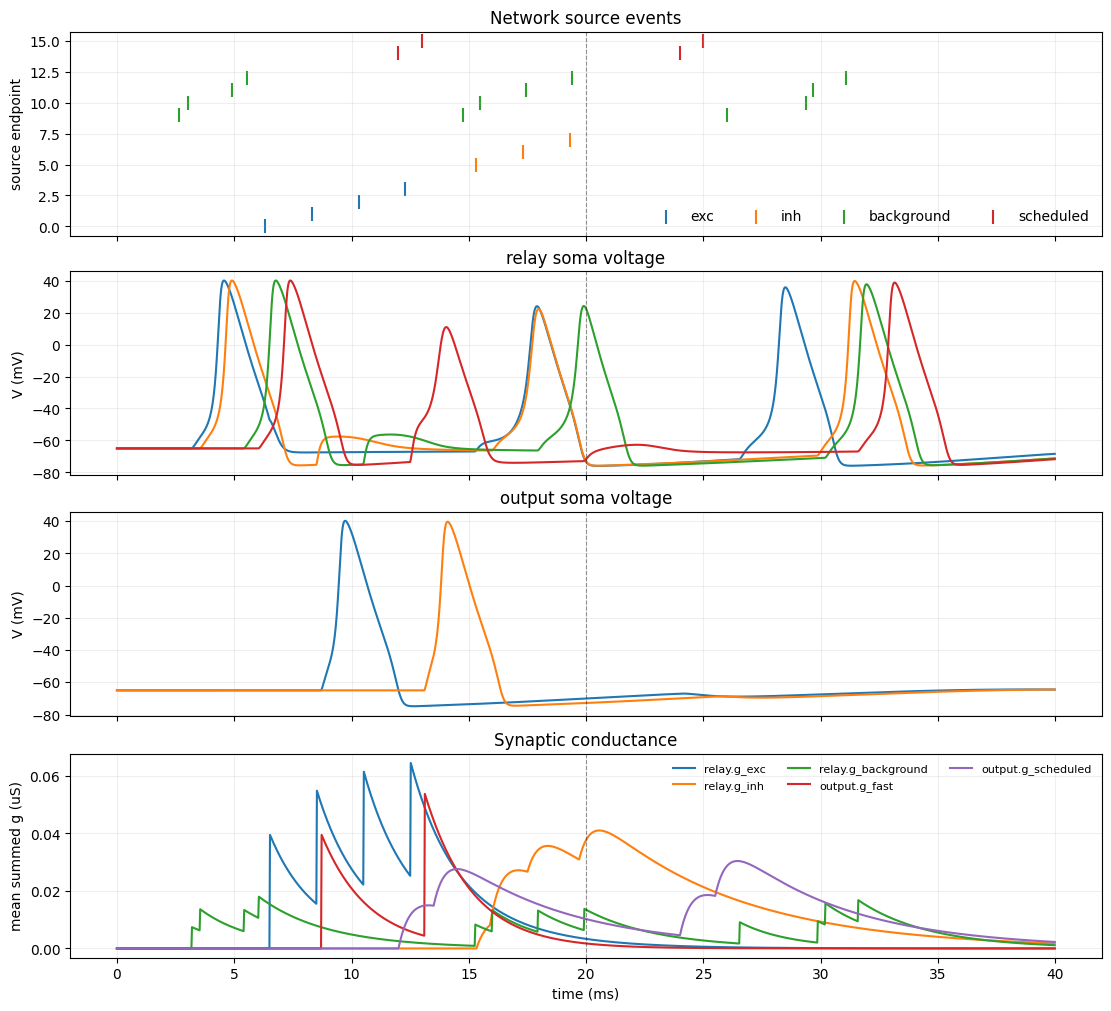

In [13]:
def sum_synapses_by_cell(block, population_size):
    values = np.asarray(block.values.to_decimal(u.uS))
    owners = np.asarray([row.population_index for row in block.schema.rows])
    summed = np.zeros((values.shape[0], population_size))
    for column, owner in enumerate(owners):
        summed[:, owner] += values[:, column]
    return summed


fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True, constrained_layout=True)
offset = 0
for population, port in source_ports:
    events = result.events[population][port]
    axes[0].scatter(
        events.time.to_decimal(u.ms), events.source_id + offset,
        marker="|", s=90, label=population,
    )
    offset += network.populations[population].size + 1
axes[0].set(ylabel="source endpoint", title="Network source events")
axes[0].legend(ncol=4, frameon=False)

relay_v = result.samples["relay"]["v_soma"]
output_v = result.samples["output"]["v_soma"]
axes[1].plot(relay_v.time.to_decimal(u.ms), relay_v.values.to_decimal(u.mV))
axes[1].set(ylabel="V (mV)", title="relay soma voltage")
axes[2].plot(output_v.time.to_decimal(u.ms), output_v.values.to_decimal(u.mV))
axes[2].set(ylabel="V (mV)", title="output soma voltage")

for population, name, size in [
    ("relay", "g_exc", 4), ("relay", "g_inh", 4),
    ("relay", "g_background", 4),
    ("output", "g_fast", 2), ("output", "g_scheduled", 2),
]:
    block = result.samples[population][name]
    mean_g = sum_synapses_by_cell(block, size).mean(axis=1)
    axes[3].plot(block.time.to_decimal(u.ms), mean_g, label=f"{population}.{name}")
axes[3].set(xlabel="time (ms)", ylabel="mean summed g (uS)", title="Synaptic conductance")
axes[3].legend(ncol=3, frameon=False, fontsize=8)
for ax in axes:
    ax.axvline(20.0, color="black", linestyle="--", linewidth=0.8, alpha=0.4)
    ax.grid(alpha=0.2)

## 总结

- Population 是 Cell、NetStim 和 EventSequence 的统一命名/所有权层，并暴露 event outputs；Cell Population 还转发 synapses 和 connections。
- `Network.connect()` 既能连接已有 SynapseView，也能原子执行 place-and-connect；两条路径落入同一 Connection store。
- live Cell source 的 owner 必须和 target 一起被 Network 推进；scheduled sources 也注册为 Population，以便查询、seed 管理和结果归档。
- `record()` 仍声明在 Cell/view 上；NetworkResult 按 population name 返回带 schema 的 SampleBlock 和稀疏 EventSeries。
- 连续 `run()` 延续时间与状态，`reset_state()` 只重置 runtime，不重新开放 topology。